In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import os.path as op

from specula.mmlib.analyse_data import get_sim_data
root_dir = '/raid1/mmenessini/calibration/FSOC'
result_dir = '/raid1/mmenessini/results/FSOC'

2026-07-31 11:01:38,095 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-07-31 11:01:38,227 [INFO]: [specula]: Default device is GPU number 0
2026-07-31 11:01:38,410 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-07-31 11:01:38,411 [INFO]: [specula]: Default device is GPU number 0


In [2]:
import matplotlib as mpl
from cycler import cycler

cmap = mpl.colormaps['hot'] # 1. Choose your colormap (e.g., 'hot', 'jet', 'turbo')
colors = cmap(np.linspace(0.1, 0.9, 7)) # 2. Extract a set of colors from it (e.g., 6 distinct colors across the map)
plt.rcParams['axes.prop_cycle'] = cycler(color=colors) # 3. Apply it to the default line cycle
plt.rcParams['image.cmap'] = 'hot' # 4. Change the default colormap for images/scatter plots
plt.rcParams.update({
    "text.usetex": True, # Use LaTeX to write all text
    "font.family": "serif", # Use a serif font
    "font.serif": ["Computer Modern Roman"] # Specifically use the classic LaTeX font
})
plt.rcParams['image.origin'] = 'lower'

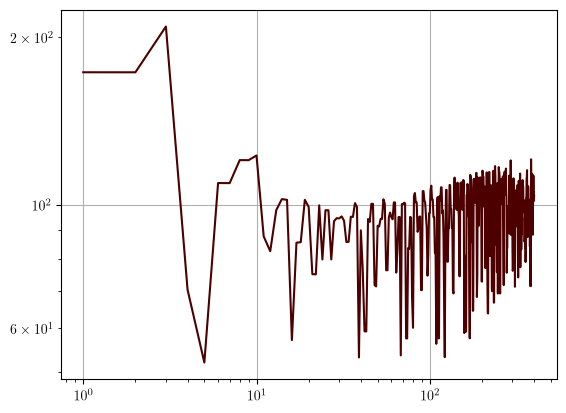

In [3]:
rec = fits.getdata(op.join(root_dir,'rec','pyr0.0_40x40_400modes_rec.fits'))

cov = np.diag(rec @ rec.T)
x = np.arange(len(cov))+1

plt.figure()
plt.loglog(x,cov)
plt.grid()

In [4]:
data = get_sim_data(result_dir) #,tn='20260717_105422'

atmo_res = data['atmo_res']
dm_res = data['dm_res']

Using data directory: /raid1/mmenessini/results/FSOC/20260731_110034
key: sr type: <class 'numpy.ndarray'>
key: atmo_phase type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_modes type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>


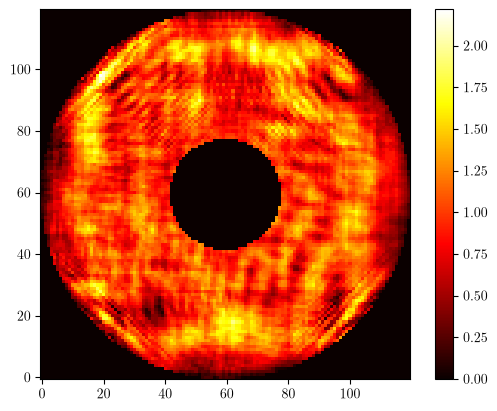

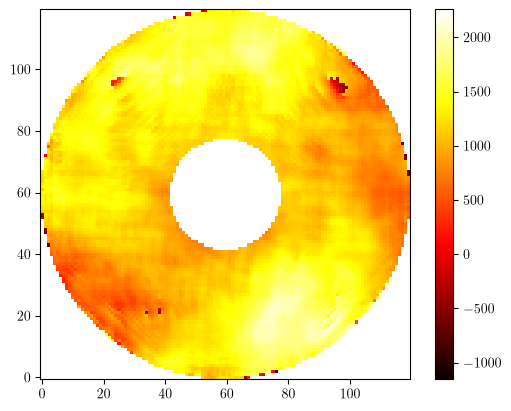

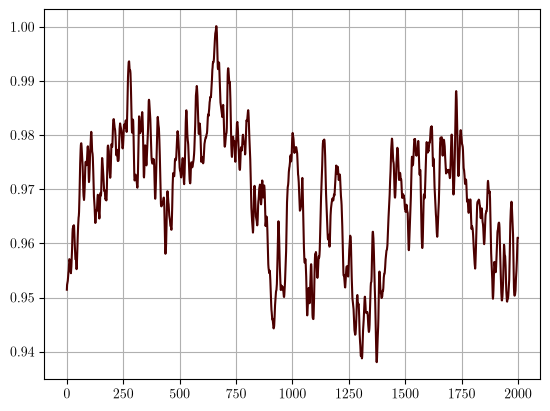

In [5]:
atmo_amp = data['atmo_phase'][:,0,:,:]
atmo_phi = data['atmo_phase'][:,1,:,:]

plt.figure()
plt.imshow(atmo_amp[1000])
plt.colorbar()

plt.figure()
plt.imshow(np.ma.masked_array(atmo_phi[1000],mask=atmo_amp[0]==0))
plt.colorbar()

plt.figure()
plt.plot(np.mean(atmo_amp,axis=(1,2))/np.sum(atmo_amp[0]!=0)*np.size(atmo_amp[0]))
plt.grid()

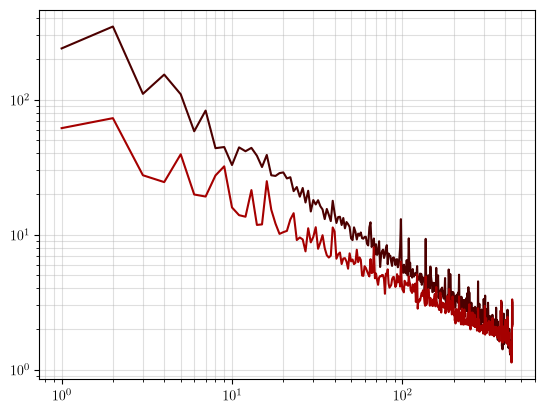

In [6]:
init = 400
atmo_res_rms = np.sqrt(np.mean(atmo_res[init:]**2,axis=0))
dm_res_rms = np.sqrt(np.mean(dm_res[init:]**2,axis=0))

x = np.arange(dm_res.shape[1])+1

plt.figure()
plt.loglog(x,atmo_res_rms)
plt.loglog(x,dm_res_rms)
plt.grid(alpha=0.4,which='both')